
STEP 1 — Loading data
  Train : train_preprocessed.csv  →  (107740, 195)
  Test  : test_preprocessed.csv   →  (55945, 195)
  Features    : 194
  Train rows  : 107740
  Test  rows  : 55945
  Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

STEP 2 — Feature Selection

  [Baseline] All Features  →  194 features

  [Filter] Mutual Information
    k=20  →  100.06s  |  top features: ['dur', 'spkts', 'sbytes', 'dbytes', 'rate', 'sttl']

  [Filter] Chi-Square
    k=20  →  0.23s  |  top features: ['rate', 'sttl', 'dttl', 'dload', 'swin', 'ct_srv_src']

  [Wrapper] RFE  (k=20, estimator=LinearSVC, step=0.3)
    done  →  59.50s  |  selected: ['spkts', 'sbytes', 'dbytes', 'dttl', 'dload', 'sinpkt']

  [Wrapper] SFS  (k=20, estimator=RandomForest n=20, cv=2)
    done  →  1404.86s  |  selected: ['sbytes', 'sttl', 'ct_state_ttl', 'is_sm_ips_ports', 'proto_any', 'proto_arp']

  ── Selected feature subsets ──────────────────────────────
  MI k=20     : ['dur', 'spkts', 'sbytes', 'dbyt

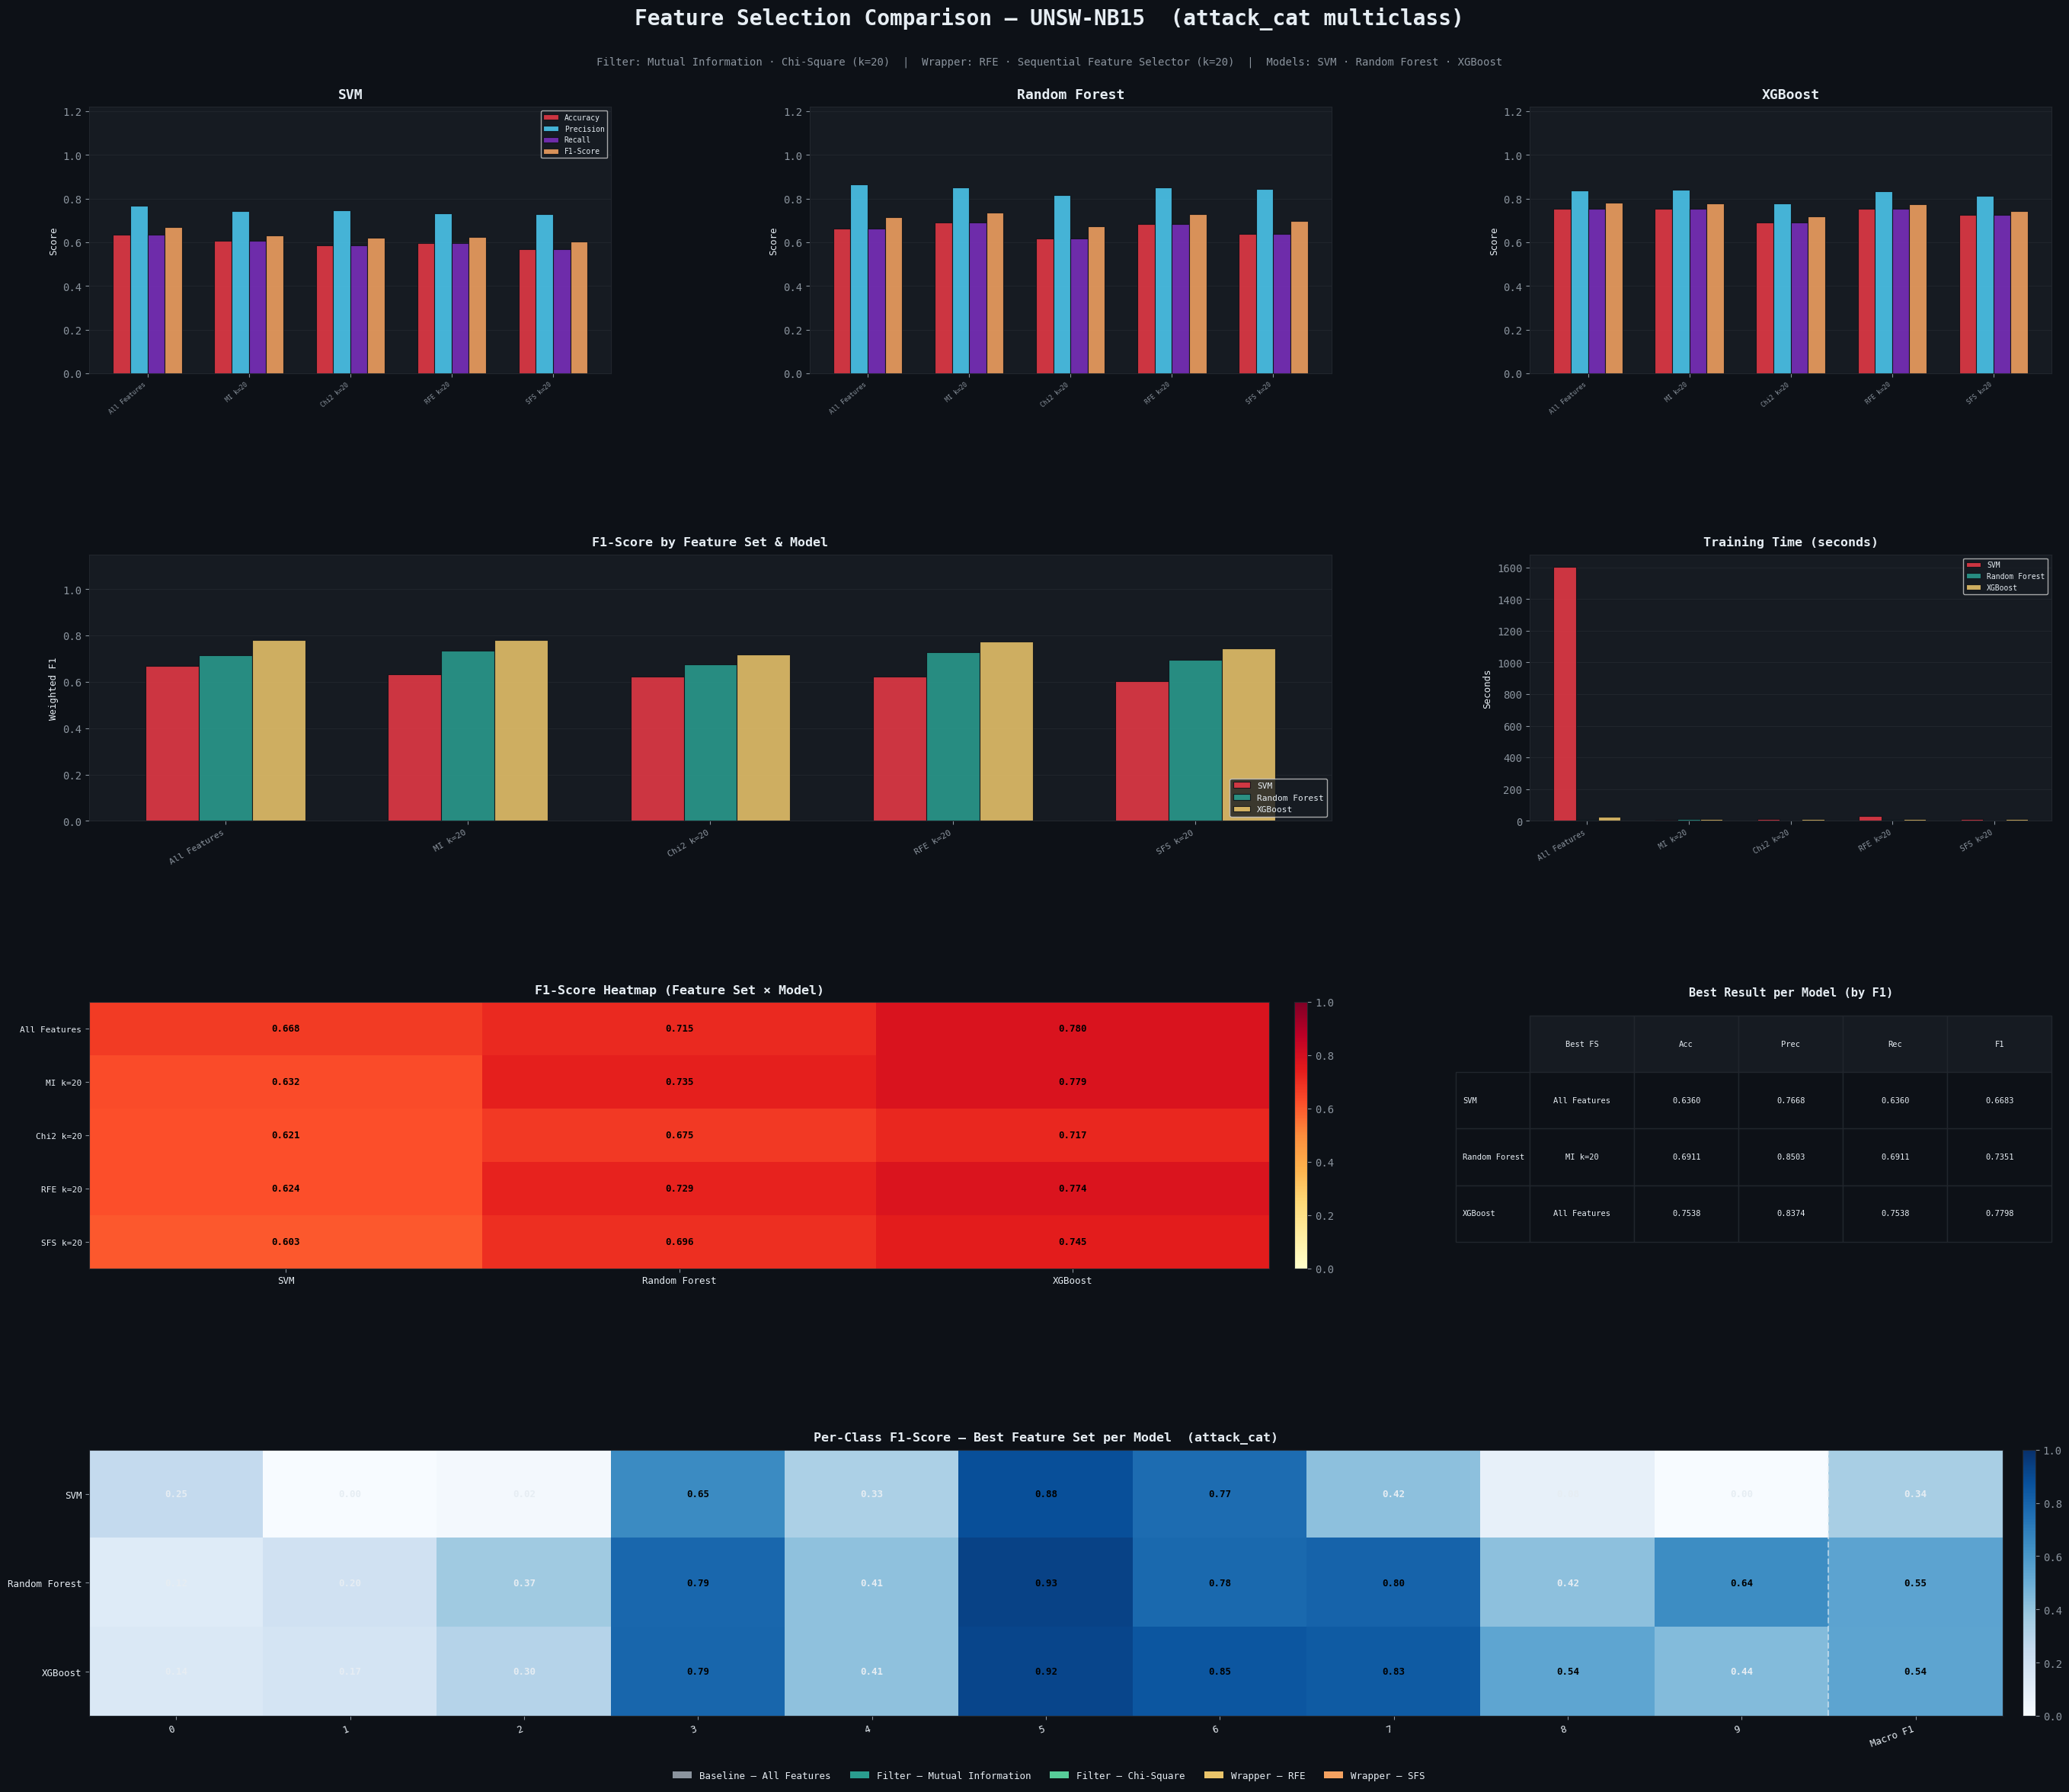


✓ All done!


In [1]:
# ══════════════════════════════════════════════════════════════════
# CONFIGURATION — edit these if needed
# ══════════════════════════════════════════════════════════════════
TRAIN_FILE  = "train_preprocessed.csv"
TEST_FILE   = "test_preprocessed.csv"
TARGET_COL  = "attack_cat"
K_VALUES    = [20]
K_WRAPPER   = 20
SAMPLE_SIZE = None
# ══════════════════════════════════════════════════════════════════

import time
import warnings
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import (
    SelectKBest, mutual_info_classif, chi2,
    RFE, SequentialFeatureSelector
)
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[WARNING] xgboost not installed — pip install xgboost")

warnings.filterwarnings("ignore")


# ──────────────────────────────────────────────────────────────────
# STEP 1 — LOAD DATA
# ──────────────────────────────────────────────────────────────────
def load_data():
    print("\n" + "="*60)
    print("STEP 1 — Loading data")
    print("="*60)

    train_df = pd.read_csv(TRAIN_FILE, low_memory=False)
    test_df  = pd.read_csv(TEST_FILE,  low_memory=False)
    print(f"  Train : {TRAIN_FILE}  →  {train_df.shape}")
    print(f"  Test  : {TEST_FILE}   →  {test_df.shape}")

    if TARGET_COL not in train_df.columns:
        sys.exit(f"[ERROR] '{TARGET_COL}' not found. "
                 f"Columns: {list(train_df.columns)}")

    X_train = train_df.drop(columns=[TARGET_COL])
    X_test  = test_df.drop(columns=[TARGET_COL])
    y_train = train_df[TARGET_COL].values
    y_test  = test_df[TARGET_COL].values

    shared  = [c for c in X_train.columns if c in X_test.columns]
    X_train, X_test = X_train[shared], X_test[shared]

    le = LabelEncoder()
    y_train = le.fit_transform(y_train.astype(str))
    y_test  = le.transform(y_test.astype(str))
    class_names = le.classes_

    print(f"  Features    : {X_train.shape[1]}")
    print(f"  Train rows  : {len(y_train)}")
    print(f"  Test  rows  : {len(y_test)}")
    print(f"  Classes ({len(class_names)}): {list(class_names)}")
    return X_train, X_test, y_train, y_test, class_names


# ──────────────────────────────────────────────────────────────────
# STEP 2 — FEATURE SELECTION
# ──────────────────────────────────────────────────────────────────
def select_features(X_train_df, X_test_df, y_train, feat_names):
    print("\n" + "="*60)
    print("STEP 2 — Feature Selection")
    print("="*60)

    X_tr = X_train_df.values.astype(float)
    X_te = X_test_df.values.astype(float)

    X_tr_nn = np.clip(X_tr, 0, None)
    X_te_nn = np.clip(X_te, 0, None)

    feature_sets = {}

    # ── 1. All Features (baseline) ────────────────────────────────
    print(f"\n  [Baseline] All Features  →  {X_tr.shape[1]} features")
    feature_sets["All Features"] = {
        "X_tr": X_tr, "X_te": X_te,
        "n": X_tr.shape[1],
        "method": "Baseline",
        "features": feat_names
    }

    # ── 2. Filter: Mutual Information ─────────────────────────────
    print("\n  [Filter] Mutual Information")
    for k in K_VALUES:
        if k >= X_tr.shape[1]:
            print(f"    k={k} skipped (>= total features)")
            continue
        t0  = time.perf_counter()
        sel = SelectKBest(mutual_info_classif, k=k)
        Xtr_s = sel.fit_transform(X_tr, y_train)
        Xte_s = sel.transform(X_te)
        t   = time.perf_counter() - t0
        mask  = sel.get_support()
        feats = [f for f, m in zip(feat_names, mask) if m]
        label = f"MI k={k}"
        feature_sets[label] = {
            "X_tr": Xtr_s, "X_te": Xte_s,
            "n": k, "method": "Filter (MI)",
            "sel_time": round(t, 2), "features": feats
        }
        print(f"    k={k:2d}  →  {t:.2f}s  |  top features: {feats[:6]}")

    # ── 3. Filter: Chi-Square ─────────────────────────────────────
    print("\n  [Filter] Chi-Square")
    for k in K_VALUES:
        if k >= X_tr.shape[1]:
            print(f"    k={k} skipped (>= total features)")
            continue
        t0  = time.perf_counter()
        sel = SelectKBest(chi2, k=k)
        Xtr_s = sel.fit_transform(X_tr_nn, y_train)
        Xte_s = sel.transform(X_te_nn)
        t   = time.perf_counter() - t0
        mask  = sel.get_support()
        feats = [f for f, m in zip(feat_names, mask) if m]
        label = f"Chi2 k={k}"
        feature_sets[label] = {
            "X_tr": Xtr_s, "X_te": Xte_s,
            "n": k, "method": "Filter (Chi2)",
            "sel_time": round(t, 2), "features": feats
        }
        print(f"    k={k:2d}  →  {t:.2f}s  |  top features: {feats[:6]}")

    # ── 4. Wrapper: RFE ───────────────────────────────────────────
    print(f"\n  [Wrapper] RFE  (k={K_WRAPPER}, estimator=LinearSVC, step=0.3)")
    t0  = time.perf_counter()
    rfe = RFE(LinearSVC(max_iter=5000, C=1, random_state=42),
              n_features_to_select=K_WRAPPER, step=0.3)
    Xtr_rfe = rfe.fit_transform(X_tr, y_train)
    Xte_rfe = rfe.transform(X_te)
    t       = time.perf_counter() - t0
    feats_rfe = [f for f, m in zip(feat_names, rfe.support_) if m]
    feature_sets[f"RFE k={K_WRAPPER}"] = {
        "X_tr": Xtr_rfe, "X_te": Xte_rfe,
        "n": K_WRAPPER, "method": "Wrapper (RFE)",
        "sel_time": round(t, 2), "features": feats_rfe
    }
    print(f"    done  →  {t:.2f}s  |  selected: {feats_rfe[:6]}")

    # ── 5. Wrapper: SFS ───────────────────────────────────────────
    print(f"\n  [Wrapper] SFS  (k={K_WRAPPER}, estimator=RandomForest n=20, cv=2)")
    t0  = time.perf_counter()
    sfs = SequentialFeatureSelector(
        RandomForestClassifier(
            n_estimators=20, max_depth=8,
            n_jobs=-1, random_state=42
        ),
        n_features_to_select=K_WRAPPER,
        direction="forward",
        scoring="accuracy",
        cv=2,
        n_jobs=-1
    )
    sfs.fit(X_tr, y_train)
    Xtr_sfs = sfs.transform(X_tr)
    Xte_sfs = sfs.transform(X_te)
    t       = time.perf_counter() - t0
    feats_sfs = [f for f, m in zip(feat_names, sfs.get_support()) if m]
    feature_sets[f"SFS k={K_WRAPPER}"] = {
        "X_tr": Xtr_sfs, "X_te": Xte_sfs,
        "n": K_WRAPPER, "method": "Wrapper (SFS)",
        "sel_time": round(t, 2), "features": feats_sfs
    }
    print(f"    done  →  {t:.2f}s  |  selected: {feats_sfs[:6]}")

    print("\n  ── Selected feature subsets ──────────────────────────────")
    for label, fs in feature_sets.items():
        if label != "All Features":
            print(f"  {label:12s}: {fs['features']}")

    return feature_sets


# ──────────────────────────────────────────────────────────────────
# STEP 3 — TRAIN & EVALUATE
# ──────────────────────────────────────────────────────────────────
def get_models(n_classes):
    models = {
        "SVM": make_pipeline(
            StandardScaler(),
            LinearSVC(C=10, max_iter=5000, random_state=42)
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=22, criterion="gini",
            min_samples_split=6, n_jobs=-1, random_state=42,
            class_weight="balanced"
        ),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
            objective="multi:softmax", num_class=n_classes,
            use_label_encoder=False, eval_metric="mlogloss",
            n_jobs=-1, random_state=42
        )
    return models


def evaluate(model, X_tr, y_tr, X_te, y_te, class_names):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    y_pred = model.predict(X_te)
    report = classification_report(
        y_te, y_pred, target_names=class_names,
        output_dict=True, zero_division=0
    )
    return {
        "accuracy":  round(accuracy_score(y_te, y_pred), 4),
        "precision": round(precision_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "recall":    round(recall_score(y_te, y_pred,    average="weighted", zero_division=0), 4),
        "f1":        round(f1_score(y_te, y_pred,        average="weighted", zero_division=0), 4),
        "time":      round(train_time, 3),
        "per_class": report,
    }


def print_detailed_report(mname, fs_label, m, class_names):
    pc = m["per_class"]
    print(f"\n  === {mname} | {fs_label} ===")
    print(f"  Accuracy: {m['accuracy']:.4f}   "
          f"Weighted F1: {m['f1']:.4f}   "
          f"Macro F1: {round(pc.get('macro avg', {}).get('f1-score', 0), 4)}")
    print()
    header = f"  {'':>20}  {'precision':>10}  {'recall':>10}  {'f1-score':>10}  {'support':>10}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for cls in class_names:
        r = pc.get(cls, {})
        print(f"  {cls:>20}  "
              f"{r.get('precision', 0):>10.2f}  "
              f"{r.get('recall',    0):>10.2f}  "
              f"{r.get('f1-score',  0):>10.2f}  "
              f"{int(r.get('support', 0)):>10}")
    print()
    for avg in ["accuracy", "macro avg", "weighted avg"]:
        r = pc.get(avg, {})
        if avg == "accuracy":
            print(f"  {'accuracy':>20}  {'':>10}  {'':>10}  "
                  f"{m['accuracy']:>10.2f}  "
                  f"{int(pc.get('weighted avg', {}).get('support', 0)):>10}")
        else:
            print(f"  {avg:>20}  "
                  f"{r.get('precision', 0):>10.2f}  "
                  f"{r.get('recall',    0):>10.2f}  "
                  f"{r.get('f1-score',  0):>10.2f}  "
                  f"{int(r.get('support', 0)):>10}")
    print("  " + "="*70)


def train_and_evaluate(feature_sets, y_train, y_test, class_names):
    print("\n" + "="*60)
    print("STEP 3 — Training & Evaluation")
    print("="*60)

    n_classes = len(np.unique(y_train))
    models    = get_models(n_classes)
    results   = {}
    rows      = []

    for mname, model in models.items():
        print(f"\n  ── {mname} ──────────────────────────────────────────")
        results[mname] = {}
        for fs_label, fs in feature_sets.items():
            print(f"    {fs_label:14s} ({fs['n']:2d} features) …", end=" ", flush=True)
            m = evaluate(clone(model),
                         fs["X_tr"], y_train,
                         fs["X_te"], y_test,
                         class_names)
            results[mname][fs_label] = {**m, "n_features": fs["n"],
                                         "method": fs["method"]}
            rows.append({
                "Model":         mname,
                "Feature Set":   fs_label,
                "Method":        fs["method"],
                "# Features":    fs["n"],
                "Accuracy":      m["accuracy"],
                "Precision":     m["precision"],
                "Recall":        m["recall"],
                "F1-Score":      m["f1"],
                "Train Time(s)": m["time"],
            })
            print(f"done  ({m['time']:.2f}s)")
            print_detailed_report(mname, fs_label, m, class_names)

    return results, pd.DataFrame(rows)


# ──────────────────────────────────────────────────────────────────
# STEP 4 — CHARTS
# ──────────────────────────────────────────────────────────────────
BG, CARD, GRID = "#0D1117", "#161B22", "#21262D"
TEXT, SUB       = "#E6EDF3", "#8B949E"
MODEL_COLORS    = ["#E63946", "#2A9D8F", "#E9C46A"]
METRIC_COLORS   = ["#E63946", "#4CC9F0", "#7B2FBE", "#F4A261"]


def plot_report(results, summary_df, feature_sets, class_names):
    print("\n" + "="*60)
    print("STEP 4 — Generating charts")
    print("="*60)

    plt.rcParams.update({
        "font.family": "monospace", "text.color": TEXT,
        "axes.facecolor": CARD, "figure.facecolor": BG,
        "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
        "xtick.color": SUB, "ytick.color": SUB,
        "grid.color": GRID, "grid.linewidth": 0.7,
    })

    models    = list(results.keys())
    fs_labels = list(next(iter(results.values())).keys())
    n_fs      = len(fs_labels)
    x         = np.arange(n_fs)
    bw        = 0.17
    bw2       = 0.22

    fig = plt.figure(figsize=(28, 24))
    gs  = gridspec.GridSpec(4, 3, figure=fig,
                            hspace=0.68, wspace=0.38,
                            left=0.05, right=0.97,
                            top=0.93, bottom=0.05)

    fig.text(0.5, 0.975,
             "Feature Selection Comparison — UNSW-NB15  (attack_cat multiclass)",
             ha="center", fontsize=20, fontweight="bold", color=TEXT)
    fig.text(0.5, 0.953,
             "Filter: Mutual Information · Chi-Square (k=20)  |  "
             "Wrapper: RFE · Sequential Feature Selector (k=20)  |  "
             "Models: SVM · Random Forest · XGBoost",
             ha="center", fontsize=10, color=SUB)

    metrics  = ["accuracy", "precision", "recall", "f1"]
    met_disp = ["Accuracy", "Precision", "Recall", "F1-Score"]

    # ROW 0 — per-model metric bars
    for mi, mname in enumerate(models):
        ax = fig.add_subplot(gs[0, mi])
        for ji, (mk, md, mc) in enumerate(zip(metrics, met_disp, METRIC_COLORS)):
            vals = [results[mname][fs][mk] for fs in fs_labels]
            ax.bar(x + (ji - 1.5)*bw, vals, width=bw,
                   color=mc, alpha=0.88, edgecolor=BG,
                   linewidth=0.8, label=md, zorder=3)
        ax.set_xticks(x)
        ax.set_xticklabels(fs_labels, fontsize=6, rotation=40, ha="right")
        ax.set_ylim(0, 1.22)
        ax.set_title(mname, fontsize=13, fontweight="bold", color=TEXT, pad=8)
        ax.set_ylabel("Score", fontsize=9)
        ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
        if mi == 0:
            ax.legend(fontsize=7, loc="upper right",
                      frameon=True, facecolor=CARD, labelcolor=TEXT)

    # ROW 1 left+mid — F1 grouped by model
    ax_f1 = fig.add_subplot(gs[1, :2])
    for mi, (mname, mc) in enumerate(zip(models, MODEL_COLORS)):
        vals = [results[mname][fs]["f1"] for fs in fs_labels]
        ax_f1.bar(x + (mi - len(models)/2 + 0.5)*bw2, vals,
                  width=bw2, color=mc, alpha=0.88, edgecolor=BG,
                  linewidth=0.8, label=mname, zorder=3)
    ax_f1.set_xticks(x)
    ax_f1.set_xticklabels(fs_labels, fontsize=8, rotation=30, ha="right")
    ax_f1.set_ylim(0, 1.15)
    ax_f1.set_title("F1-Score by Feature Set & Model",
                    fontsize=12, fontweight="bold", color=TEXT, pad=8)
    ax_f1.set_ylabel("Weighted F1", fontsize=9)
    ax_f1.grid(axis="y", zorder=0); ax_f1.set_axisbelow(True)
    ax_f1.legend(fontsize=8, loc="lower right",
                 frameon=True, facecolor=CARD, labelcolor=TEXT)

    # ROW 1 right — training time
    ax_t = fig.add_subplot(gs[1, 2])
    for mi, (mname, mc) in enumerate(zip(models, MODEL_COLORS)):
        times = [results[mname][fs]["time"] for fs in fs_labels]
        ax_t.bar(x + (mi - len(models)/2 + 0.5)*bw2, times,
                 width=bw2, color=mc, alpha=0.88, edgecolor=BG,
                 linewidth=0.8, label=mname, zorder=3)
    ax_t.set_xticks(x)
    ax_t.set_xticklabels(fs_labels, fontsize=7, rotation=30, ha="right")
    ax_t.set_title("Training Time (seconds)",
                   fontsize=12, fontweight="bold", color=TEXT, pad=8)
    ax_t.set_ylabel("Seconds", fontsize=9)
    ax_t.grid(axis="y", zorder=0); ax_t.set_axisbelow(True)
    ax_t.legend(fontsize=7, frameon=True, facecolor=CARD, labelcolor=TEXT)

    # ROW 2 left+mid — F1 heatmap
    ax_heat = fig.add_subplot(gs[2, :2])
    heat_df = pd.DataFrame(
        {m: [results[m][fs]["f1"] for fs in fs_labels] for m in models},
        index=fs_labels
    )
    im = ax_heat.imshow(heat_df.values, cmap="YlOrRd",
                        aspect="auto", vmin=0, vmax=1)
    ax_heat.set_xticks(range(len(models)))
    ax_heat.set_xticklabels(models, fontsize=9, color=TEXT)
    ax_heat.set_yticks(range(n_fs))
    ax_heat.set_yticklabels(fs_labels, fontsize=8, color=TEXT)
    ax_heat.set_title("F1-Score Heatmap (Feature Set × Model)",
                      fontsize=12, fontweight="bold", color=TEXT, pad=8)
    for i in range(n_fs):
        for j in range(len(models)):
            val = heat_df.values[i, j]
            ax_heat.text(j, i, f"{val:.3f}", ha="center", va="center",
                         fontsize=9, fontweight="bold",
                         color="black" if val > 0.5 else TEXT)
    plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02)

    # ROW 2 right — best per model table
    ax_tbl = fig.add_subplot(gs[2, 2])
    ax_tbl.axis("off")
    ax_tbl.set_title("Best Result per Model (by F1)",
                     fontsize=11, fontweight="bold", color=TEXT, pad=6)
    tbl_rows, tbl_labels = [], []
    for mname in models:
        best = max(results[mname], key=lambda f: results[mname][f]["f1"])
        r = results[mname][best]
        tbl_rows.append([best,
                         f"{r['accuracy']:.4f}",
                         f"{r['precision']:.4f}",
                         f"{r['recall']:.4f}",
                         f"{r['f1']:.4f}"])
        tbl_labels.append(mname)
    tbl = ax_tbl.table(
        cellText=tbl_rows, rowLabels=tbl_labels,
        colLabels=["Best FS", "Acc", "Prec", "Rec", "F1"],
        cellLoc="center", loc="center", bbox=[0, 0.1, 1, 0.85]
    )
    tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor(CARD if r == 0 else BG)
        cell.set_edgecolor(GRID)
        cell.set_text_props(color=TEXT)

    # ROW 3 — per-class F1 heatmap
    ax_pc = fig.add_subplot(gs[3, :])
    best_pc = {}
    for mname in models:
        best_fs = max(results[mname], key=lambda f: results[mname][f]["f1"])
        best_pc[mname] = results[mname][best_fs]["per_class"]

    pc_data = np.array([
        [best_pc[m].get(c, {}).get("f1-score", 0) for c in class_names]
        for m in models
    ])
    macro_col = np.array([
        [best_pc[m].get("macro avg", {}).get("f1-score", 0)]
        for m in models
    ])
    pc_data_ext  = np.hstack([pc_data, macro_col])
    col_labels   = list(class_names) + ["Macro F1"]

    im2 = ax_pc.imshow(pc_data_ext, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax_pc.set_xticks(range(len(col_labels)))
    ax_pc.set_xticklabels(col_labels, fontsize=9, color=TEXT,
                           rotation=20, ha="right")
    ax_pc.axvline(x=len(class_names) - 0.5, color=TEXT,
                  linewidth=1.5, linestyle="--", alpha=0.6)
    ax_pc.set_yticks(range(len(models)))
    ax_pc.set_yticklabels(models, fontsize=9, color=TEXT)
    ax_pc.set_title(
        "Per-Class F1-Score — Best Feature Set per Model  (attack_cat)",
        fontsize=12, fontweight="bold", color=TEXT, pad=8)
    for i in range(len(models)):
        for j in range(len(col_labels)):
            val = pc_data_ext[i, j]
            ax_pc.text(j, i, f"{val:.2f}", ha="center", va="center",
                       fontsize=9, fontweight="bold",
                       color="black" if val > 0.5 else TEXT)
    plt.colorbar(im2, ax=ax_pc, fraction=0.015, pad=0.01)

    legend_els = [
        Patch(facecolor="#8B949E", label="Baseline — All Features"),
        Patch(facecolor="#2A9D8F", label="Filter — Mutual Information"),
        Patch(facecolor="#57CC99", label="Filter — Chi-Square"),
        Patch(facecolor="#E9C46A", label="Wrapper — RFE"),
        Patch(facecolor="#F4A261", label="Wrapper — SFS"),
    ]
    fig.legend(handles=legend_els, loc="lower center", ncol=5,
               frameon=False, fontsize=9, labelcolor=TEXT,
               bbox_to_anchor=(0.5, 0.01))

    plt.show()


# ──────────────────────────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    X_train, X_test, y_train, y_test, class_names = load_data()
    feature_sets = select_features(X_train, X_test, y_train, list(X_train.columns))
    results, summary_df = train_and_evaluate(feature_sets, y_train, y_test, class_names)
    plot_report(results, summary_df, feature_sets, class_names)
    print("\n✓ All done!")

In [15]:
    # ─────────────────────────────────────────────────────────────
    # FEATURE OVERLAP ANALYSIS
    # ─────────────────────────────────────────────────────────────
    from itertools import combinations

    print("\n" + "="*60)
    print("FEATURE OVERLAP ANALYSIS")
    print("="*60)

    # remove baseline
    fs_compare = {
        k: v["features"]
        for k, v in feature_sets.items()
        if k != "All Features"
    }

    for (name1, feats1), (name2, feats2) in combinations(fs_compare.items(), 2):

        set1 = set(feats1)
        set2 = set(feats2)

        overlap = set1 & set2

        overlap_count = len(overlap)

        overlap_percent = (
            overlap_count / min(len(set1), len(set2))
        ) * 100

        print(f"\n{name1} ∩ {name2}")
        print("-" * 50)

        print(f"Overlap Count      : {overlap_count}")
        print(f"Overlap Percentage : {overlap_percent:.2f}%")

        print("\nShared Features:")
        if overlap:
            for f in sorted(overlap):
                print(f"  - {f}")
        else:
            print("  None")


FEATURE OVERLAP ANALYSIS

MI k=20 ∩ Chi2 k=20
--------------------------------------------------
Overlap Count      : 6
Overlap Percentage : 30.00%

Shared Features:
  - ct_srv_src
  - ct_state_ttl
  - dload
  - dttl
  - rate
  - sttl

MI k=20 ∩ RFE k=20
--------------------------------------------------
Overlap Count      : 13
Overlap Percentage : 65.00%

Shared Features:
  - ct_srv_src
  - dbytes
  - dinpkt
  - dload
  - dmean
  - dttl
  - sbytes
  - sinpkt
  - sjit
  - smean
  - spkts
  - synack
  - tcprtt

MI k=20 ∩ SFS k=20
--------------------------------------------------
Overlap Count      : 3
Overlap Percentage : 15.00%

Shared Features:
  - ct_state_ttl
  - sbytes
  - sttl

Chi2 k=20 ∩ RFE k=20
--------------------------------------------------
Overlap Count      : 7
Overlap Percentage : 35.00%

Shared Features:
  - ct_dst_sport_ltm
  - ct_srv_src
  - dload
  - dttl
  - proto_tcp
  - state_CON
  - state_FIN

Chi2 k=20 ∩ SFS k=20
----------------------------------------------


EXTRA — Naïve Bayes, Decision Tree, MLP

  ── Naïve Bayes ──────────────────────────────────────────
    All Features   (194 features) … done  (0.59s)

  === Naïve Bayes | All Features ===
  Accuracy: 0.1612   Weighted F1: 0.2261   Macro F1: 0.1048
                         precision      recall    f1-score     support
  --------------------------------------------------------------------
                     0        0.19        0.48        0.28         446
                     1        0.09        0.05        0.06         346
                     2        0.42        0.00        0.01        1718
                     3        0.93        0.05        0.09        7609
                     4        0.00        0.00        0.00        4838
                     5        0.40        0.17        0.23        3657
                     6        0.61        0.22        0.32       34206
                     7        0.51        0.01        0.01        2703
                     8        0.02      

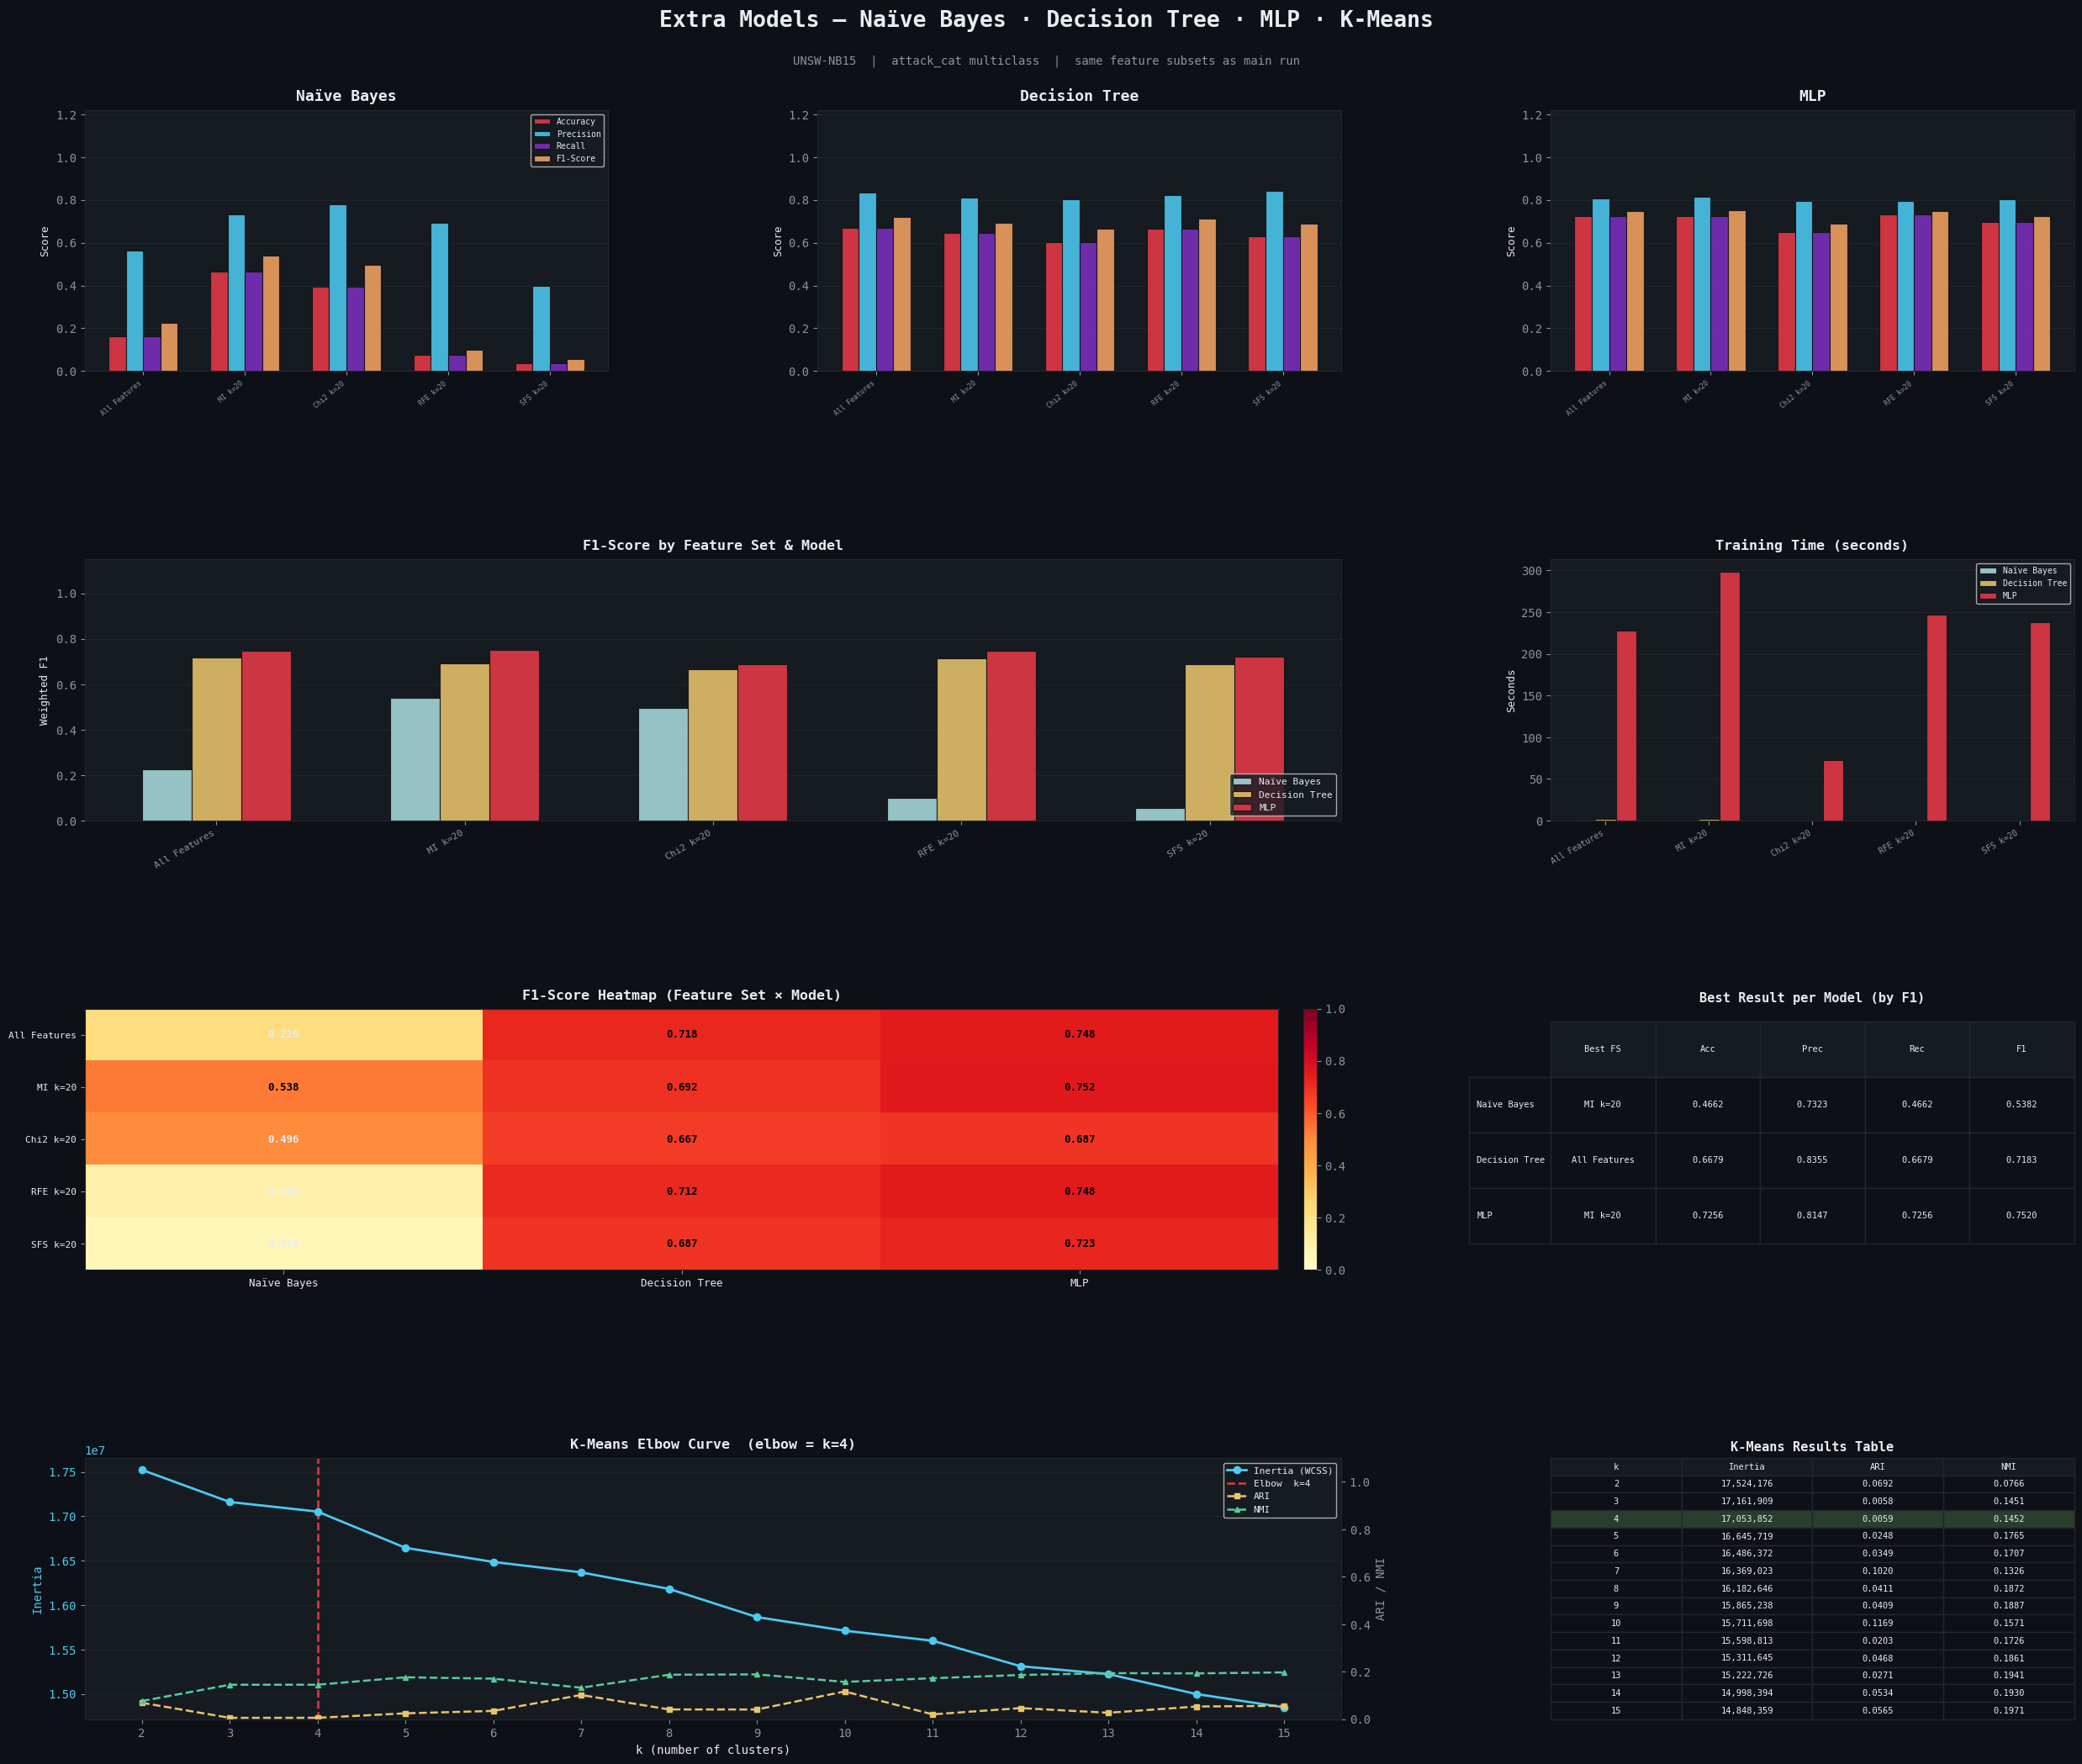


✓ Extra models done!


In [7]:
# ══════════════════════════════════════════════════════════════════
# EXTRA MODELS CELL — Naïve Bayes · Decision Tree · K-Means · MLP
# Run AFTER the main cell (reuses feature_sets, y_train, y_test, class_names)
# ══════════════════════════════════════════════════════════════════

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.naive_bayes        import GaussianNB
from sklearn.tree               import DecisionTreeClassifier
from sklearn.neural_network     import MLPClassifier
from sklearn.cluster            import KMeans
from sklearn.preprocessing      import StandardScaler
from sklearn.pipeline           import make_pipeline
from sklearn.metrics            import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.base import clone

warnings.filterwarnings("ignore")

# ── colour palette (matches main cell) ───────────────────────────
BG, CARD, GRID  = "#0D1117", "#161B22", "#21262D"
TEXT, SUB       = "#E6EDF3", "#8B949E"
MODEL_COLORS    = ["#A8DADC", "#E9C46A", "#E63946", "#9B5DE5"]
METRIC_COLORS   = ["#E63946", "#4CC9F0", "#7B2FBE", "#F4A261"]


# ──────────────────────────────────────────────────────────────────
# HELPERS
# ──────────────────────────────────────────────────────────────────
def evaluate_clf(model, X_tr, y_tr, X_te, y_te, class_names):
    """Train a classifier and return metrics dict."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    y_pred = model.predict(X_te)
    report = classification_report(
        y_te, y_pred, target_names=class_names,
        output_dict=True, zero_division=0
    )
    return {
        "accuracy":  round(accuracy_score(y_te, y_pred), 4),
        "precision": round(precision_score(y_te, y_pred, average="weighted", zero_division=0), 4),
        "recall":    round(recall_score(y_te, y_pred,    average="weighted", zero_division=0), 4),
        "f1":        round(f1_score(y_te, y_pred,        average="weighted", zero_division=0), 4),
        "time":      round(train_time, 3),
        "per_class": report,
    }


def print_report_extra(mname, fs_label, m, class_names):
    pc = m["per_class"]
    print(f"\n  === {mname} | {fs_label} ===")
    print(f"  Accuracy: {m['accuracy']:.4f}   "
          f"Weighted F1: {m['f1']:.4f}   "
          f"Macro F1: {round(pc.get('macro avg',{}).get('f1-score',0),4)}")
    header = f"  {'':>20}  {'precision':>10}  {'recall':>10}  {'f1-score':>10}  {'support':>10}"
    print(header)
    print("  " + "-" * (len(header) - 2))
    for cls in class_names:
        r = pc.get(cls, {})
        print(f"  {cls:>20}  "
              f"{r.get('precision',0):>10.2f}  "
              f"{r.get('recall',0):>10.2f}  "
              f"{r.get('f1-score',0):>10.2f}  "
              f"{int(r.get('support',0)):>10}")
    print("  " + "="*70)


# ──────────────────────────────────────────────────────────────────
# STEP A — SUPERVISED MODELS (NB · DT · MLP)
# ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EXTRA — Naïve Bayes, Decision Tree, MLP")
print("="*60)

extra_models = {
    "Naïve Bayes": make_pipeline(
        StandardScaler(with_mean=False),   # NB is sensitive to scale
        GaussianNB()
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=5,
        criterion="gini",
        random_state=42 , 
        class_weight = "balanced"
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
}

extra_results = {}
extra_rows    = []

for mname, model in extra_models.items():
    print(f"\n  ── {mname} ──────────────────────────────────────────")
    extra_results[mname] = {}
    for fs_label, fs in feature_sets.items():
        print(f"    {fs_label:14s} ({fs['n']:2d} features) …", end=" ", flush=True)
        m = evaluate_clf(
            clone(model),
            fs["X_tr"], y_train,
            fs["X_te"], y_test,
            class_names
        )
        extra_results[mname][fs_label] = {**m, "n_features": fs["n"], "method": fs["method"]}
        extra_rows.append({
            "Model":         mname,
            "Feature Set":   fs_label,
            "Method":        fs["method"],
            "# Features":    fs["n"],
            "Accuracy":      m["accuracy"],
            "Precision":     m["precision"],
            "Recall":        m["recall"],
            "F1-Score":      m["f1"],
            "Train Time(s)": m["time"],
        })
        print(f"done  ({m['time']:.2f}s)")
        print_report_extra(mname, fs_label, m, class_names)

extra_summary_df = pd.DataFrame(extra_rows)
extra_summary_df.to_csv("extra_models_summary.csv", index=False)
print("\n  Summary CSV  →  extra_models_summary.csv")
print(extra_summary_df.to_string(index=False))


# ──────────────────────────────────────────────────────────────────
# STEP B — K-MEANS CLUSTERING (elbow method + evaluation)
# ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EXTRA — K-Means Clustering (Elbow Method)")
print("="*60)

# Use the "All Features" subset (scaled) for clustering
scaler_km  = StandardScaler()
X_km_train = scaler_km.fit_transform(feature_sets["All Features"]["X_tr"].astype(float))
X_km_test  = scaler_km.transform(feature_sets["All Features"]["X_te"].astype(float))

true_k     = len(np.unique(y_train))          # number of real classes
k_range    = range(2, true_k + 6)             # test k = 2 … true_k+5
inertias, ari_scores, nmi_scores = [], [], []

print(f"\n  Fitting K-Means for k = {k_range.start} … {k_range.stop - 1}")
for k in k_range:
    t0 = time.perf_counter()
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                max_iter=300, random_state=42)
    km.fit(X_km_train)
    labels_test = km.predict(X_km_test)
    elapsed = time.perf_counter() - t0

    inertias.append(km.inertia_)
    ari = adjusted_rand_score(y_test, labels_test)
    nmi = normalized_mutual_info_score(y_test, labels_test)
    ari_scores.append(round(ari, 4))
    nmi_scores.append(round(nmi, 4))
    print(f"    k={k:2d}  inertia={km.inertia_:,.0f}  "
          f"ARI={ari:.4f}  NMI={nmi:.4f}  ({elapsed:.1f}s)")

# ── Elbow detection (largest second-derivative drop) ─────────────
inertia_arr  = np.array(inertias)
deltas       = np.diff(inertia_arr)
second_deriv = np.diff(deltas)
elbow_idx    = int(np.argmax(np.abs(second_deriv))) + 1   # offset for diff
elbow_k      = list(k_range)[elbow_idx]
print(f"\n  ✓ Elbow detected at  k = {elbow_k}  "
      f"(inertia = {inertias[elbow_idx]:,.0f})")

kmeans_df = pd.DataFrame({
    "k": list(k_range),
    "Inertia": inertias,
    "ARI":     ari_scores,
    "NMI":     nmi_scores,
})
kmeans_df.to_csv("kmeans_elbow_summary.csv", index=False)
print("  K-Means CSV  →  kmeans_elbow_summary.csv")


# ──────────────────────────────────────────────────────────────────
# STEP C — CHARTS  (Extra models + Elbow)
# ──────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("EXTRA — Generating charts")
print("="*60)

plt.rcParams.update({
    "font.family": "monospace", "text.color": TEXT,
    "axes.facecolor": CARD, "figure.facecolor": BG,
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT,
    "xtick.color": SUB, "ytick.color": SUB,
    "grid.color": GRID, "grid.linewidth": 0.7,
})

fs_labels_e  = list(next(iter(extra_results.values())).keys())
extra_models_ = list(extra_results.keys())
n_fs_e       = len(fs_labels_e)
x_e          = np.arange(n_fs_e)
bw           = 0.20

fig = plt.figure(figsize=(26, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig,
                        hspace=0.72, wspace=0.40,
                        left=0.06, right=0.97,
                        top=0.93, bottom=0.06)

fig.text(0.5, 0.975,
         "Extra Models — Naïve Bayes · Decision Tree · MLP · K-Means",
         ha="center", fontsize=19, fontweight="bold", color=TEXT)
fig.text(0.5, 0.955,
         "UNSW-NB15  |  attack_cat multiclass  |  same feature subsets as main run",
         ha="center", fontsize=10, color=SUB)

metrics_e  = ["accuracy", "precision", "recall", "f1"]
met_disp_e = ["Accuracy", "Precision", "Recall", "F1-Score"]

# ROW 0 — per-model metric bars
for mi, mname in enumerate(extra_models_):
    ax = fig.add_subplot(gs[0, mi])
    for ji, (mk, md, mc) in enumerate(zip(metrics_e, met_disp_e, METRIC_COLORS)):
        vals = [extra_results[mname][fs][mk] for fs in fs_labels_e]
        ax.bar(x_e + (ji - 1.5) * 0.17, vals, width=0.17,
               color=mc, alpha=0.88, edgecolor=BG, linewidth=0.8,
               label=md, zorder=3)
    ax.set_xticks(x_e)
    ax.set_xticklabels(fs_labels_e, fontsize=6, rotation=40, ha="right")
    ax.set_ylim(0, 1.22)
    ax.set_title(mname, fontsize=13, fontweight="bold", color=TEXT, pad=8)
    ax.set_ylabel("Score", fontsize=9)
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
    if mi == 0:
        ax.legend(fontsize=7, loc="upper right",
                  frameon=True, facecolor=CARD, labelcolor=TEXT)

# ROW 1 left+mid — F1 grouped by model
ax_f1 = fig.add_subplot(gs[1, :2])
for mi, (mname, mc) in enumerate(zip(extra_models_, MODEL_COLORS)):
    vals = [extra_results[mname][fs]["f1"] for fs in fs_labels_e]
    ax_f1.bar(x_e + (mi - len(extra_models_)/2 + 0.5)*bw, vals,
              width=bw, color=mc, alpha=0.88, edgecolor=BG,
              linewidth=0.8, label=mname, zorder=3)
ax_f1.set_xticks(x_e)
ax_f1.set_xticklabels(fs_labels_e, fontsize=8, rotation=30, ha="right")
ax_f1.set_ylim(0, 1.15)
ax_f1.set_title("F1-Score by Feature Set & Model",
                fontsize=12, fontweight="bold", color=TEXT, pad=8)
ax_f1.set_ylabel("Weighted F1", fontsize=9)
ax_f1.grid(axis="y", zorder=0); ax_f1.set_axisbelow(True)
ax_f1.legend(fontsize=8, loc="lower right",
             frameon=True, facecolor=CARD, labelcolor=TEXT)

# ROW 1 right — training time
ax_t = fig.add_subplot(gs[1, 2])
for mi, (mname, mc) in enumerate(zip(extra_models_, MODEL_COLORS)):
    times = [extra_results[mname][fs]["time"] for fs in fs_labels_e]
    ax_t.bar(x_e + (mi - len(extra_models_)/2 + 0.5)*bw, times,
             width=bw, color=mc, alpha=0.88, edgecolor=BG,
             linewidth=0.8, label=mname, zorder=3)
ax_t.set_xticks(x_e)
ax_t.set_xticklabels(fs_labels_e, fontsize=7, rotation=30, ha="right")
ax_t.set_title("Training Time (seconds)",
               fontsize=12, fontweight="bold", color=TEXT, pad=8)
ax_t.set_ylabel("Seconds", fontsize=9)
ax_t.grid(axis="y", zorder=0); ax_t.set_axisbelow(True)
ax_t.legend(fontsize=7, frameon=True, facecolor=CARD, labelcolor=TEXT)

# ROW 2 left+mid — F1 heatmap
ax_heat = fig.add_subplot(gs[2, :2])
heat_df = pd.DataFrame(
    {m: [extra_results[m][fs]["f1"] for fs in fs_labels_e] for m in extra_models_},
    index=fs_labels_e
)
im = ax_heat.imshow(heat_df.values, cmap="YlOrRd",
                    aspect="auto", vmin=0, vmax=1)
ax_heat.set_xticks(range(len(extra_models_)))
ax_heat.set_xticklabels(extra_models_, fontsize=9, color=TEXT)
ax_heat.set_yticks(range(n_fs_e))
ax_heat.set_yticklabels(fs_labels_e, fontsize=8, color=TEXT)
ax_heat.set_title("F1-Score Heatmap (Feature Set × Model)",
                  fontsize=12, fontweight="bold", color=TEXT, pad=8)
for i in range(n_fs_e):
    for j in range(len(extra_models_)):
        val = heat_df.values[i, j]
        ax_heat.text(j, i, f"{val:.3f}", ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="black" if val > 0.5 else TEXT)
plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02)

# ROW 2 right — best per model table
ax_tbl = fig.add_subplot(gs[2, 2])
ax_tbl.axis("off")
ax_tbl.set_title("Best Result per Model (by F1)",
                 fontsize=11, fontweight="bold", color=TEXT, pad=6)
tbl_rows, tbl_labels = [], []
for mname in extra_models_:
    best = max(extra_results[mname], key=lambda f: extra_results[mname][f]["f1"])
    r = extra_results[mname][best]
    tbl_rows.append([best,
                     f"{r['accuracy']:.4f}",
                     f"{r['precision']:.4f}",
                     f"{r['recall']:.4f}",
                     f"{r['f1']:.4f}"])
    tbl_labels.append(mname)
tbl = ax_tbl.table(
    cellText=tbl_rows, rowLabels=tbl_labels,
    colLabels=["Best FS", "Acc", "Prec", "Rec", "F1"],
    cellLoc="center", loc="center", bbox=[0, 0.1, 1, 0.85]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor(CARD if r == 0 else BG)
    cell.set_edgecolor(GRID)
    cell.set_text_props(color=TEXT)

# ROW 3 — K-Means elbow + ARI/NMI
ax_elbow = fig.add_subplot(gs[3, :2])
k_list   = list(k_range)
color_in = "#4CC9F0"
color_ar = "#E9C46A"
color_nm = "#57CC99"

ax_elbow.plot(k_list, inertias, "o-", color=color_in,
              linewidth=2, markersize=6, label="Inertia (WCSS)", zorder=3)
ax_elbow.axvline(elbow_k, color="#E63946", linewidth=1.8,
                 linestyle="--", label=f"Elbow  k={elbow_k}")
ax_elbow.set_xlabel("k (number of clusters)", fontsize=10)
ax_elbow.set_ylabel("Inertia", fontsize=10, color=color_in)
ax_elbow.tick_params(axis="y", labelcolor=color_in)
ax_elbow.set_xticks(k_list)
ax_elbow.grid(axis="y", zorder=0); ax_elbow.set_axisbelow(True)
ax_elbow.set_title(f"K-Means Elbow Curve  (elbow = k={elbow_k})",
                   fontsize=12, fontweight="bold", color=TEXT, pad=8)

ax2 = ax_elbow.twinx()
ax2.plot(k_list, ari_scores, "s--", color=color_ar,
         linewidth=1.8, markersize=5, label="ARI")
ax2.plot(k_list, nmi_scores, "^--", color=color_nm,
         linewidth=1.8, markersize=5, label="NMI")
ax2.set_ylabel("ARI / NMI", fontsize=10, color=SUB)
ax2.tick_params(axis="y", labelcolor=SUB)
ax2.set_ylim(0, 1.1)

lines1, labels1 = ax_elbow.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_elbow.legend(lines1 + lines2, labels1 + labels2,
                fontsize=8, frameon=True, facecolor=CARD, labelcolor=TEXT,
                loc="upper right")

# ROW 3 right — K-Means table
ax_ktbl = fig.add_subplot(gs[3, 2])
ax_ktbl.axis("off")
ax_ktbl.set_title("K-Means Results Table",
                  fontsize=11, fontweight="bold", color=TEXT, pad=6)
km_rows = [[str(r.k), f"{r.Inertia:,.0f}", f"{r.ARI:.4f}", f"{r.NMI:.4f}"]
           for r in kmeans_df.itertuples()]
km_tbl = ax_ktbl.table(
    cellText=km_rows, rowLabels=None,
    colLabels=["k", "Inertia", "ARI", "NMI"],
    cellLoc="center", loc="center", bbox=[0, 0, 1, 1]
)
km_tbl.auto_set_font_size(False); km_tbl.set_fontsize(7.5)
for (r, c), cell in km_tbl.get_celld().items():
    face = CARD if r == 0 else BG
    # highlight elbow row
    if r > 0 and int(km_rows[r-1][0]) == elbow_k:
        face = "#2A3E2C"
    cell.set_facecolor(face)
    cell.set_edgecolor(GRID)
    cell.set_text_props(color=TEXT)

plt.savefig("extra_models_report.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
print("  Chart saved  →  extra_models_report.png")
plt.show()

print("\n✓ Extra models done!")

In [9]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.tree            import DecisionTreeClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.cluster         import KMeans
from sklearn.metrics         import (adjusted_rand_score,
                                     normalized_mutual_info_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm             import SVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (make_scorer, accuracy_score,
                                     precision_score, recall_score,
                                     f1_score, classification_report)

CV        = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
F1_SCORER = make_scorer(f1_score, average="weighted", zero_division=0)

SVM_MAX_ROWS = 5_000

GS_FS_KEY = "All Features"
X_tr_gs   = feature_sets[GS_FS_KEY]["X_tr"].astype(float)
X_te_gs   = feature_sets[GS_FS_KEY]["X_te"].astype(float)

TARGET_CLASSES = sorted(np.unique(y_test))[:10]

print("\n" + "="*60)
print(f"GRID SEARCH  —  feature set: '{GS_FS_KEY}'")
print(f"GridSearchCV  |  CV folds=3  |  scoring=weighted F1")
print(f"Per-class report for classes: {TARGET_CLASSES}")
print("="*60)

# ══════════════════════════════════════════════════════════════════
# SECTION 1 — SUPERVISED MODELS
# ══════════════════════════════════════════════════════════════════

if len(X_tr_gs) > SVM_MAX_ROWS:
    rng      = np.random.RandomState(42)
    svm_idx  = rng.choice(len(X_tr_gs), SVM_MAX_ROWS, replace=False)
    X_tr_svm = X_tr_gs[svm_idx]
    y_tr_svm = np.array(y_train)[svm_idx]
    print(f"\n  [SVM] Training subsampled to {SVM_MAX_ROWS:,} rows "
          f"(full set: {len(X_tr_gs):,})")
else:
    X_tr_svm = X_tr_gs
    y_tr_svm = y_train

supervised_gs_configs = {
    "Decision Tree": (
        Pipeline([("clf", DecisionTreeClassifier(random_state=42))]),
        {
            "clf__criterion":         ["gini", "entropy"],
            "clf__max_depth":         [5, 10, 20, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf":  [1, 2, 5],
            "clf__class_weight":      ["balanced", None],
        },
        X_tr_gs, y_train
    ),
    "Naïve Bayes": (
        Pipeline([("scaler", StandardScaler(with_mean=False)),
                  ("clf", GaussianNB())]),
        {
            "clf__var_smoothing": [1e-11, 1e-9, 1e-7, 1e-6],
        },
        X_tr_gs, y_train
    ),
    "MLP": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", MLPClassifier(max_iter=50,
                                        early_stopping=True,
                                        n_iter_no_change=5,
                                        random_state=42))]),
        {
            "clf__hidden_layer_sizes": [(64, 32), (128, 64)],
            "clf__activation":         ["relu"],
            "clf__alpha":              [1e-4, 1e-3, 1e-2],
            "clf__learning_rate_init": [1e-3, 5e-3, 1e-2],
        },
        X_tr_gs, y_train
    ),
    "SVM": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", SVC(random_state=42))]),
        {
            "clf__C":      [0.1, 1, 10, 100],
            "clf__kernel": ["rbf", "linear"],
            "clf__gamma":  ["scale", "auto"],
        },
        X_tr_svm, y_tr_svm
    ),
    "Random Forest": (
        Pipeline([("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]),
        {
            "clf__n_estimators":      [50, 100],
            "clf__max_depth":         [10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features":      ["sqrt", "log2"],
            "clf__class_weight":      ["balanced", None],
        },
        X_tr_gs, y_train
    ),
}

gs_rows        = []
all_class_rows = []

for mname, (pipe, params, X_tr_fit, y_tr_fit) in supervised_gs_configs.items():
    n_combos = 1
    for v in params.values():
        n_combos *= len(v)
    print(f"\n  ── {mname}  ({n_combos} combos × {CV.n_splits} folds) "
          f"[started {time.strftime('%H:%M:%S')}]")

    t0 = time.perf_counter()
    gs = GridSearchCV(
        pipe, params,
        scoring=F1_SCORER,
        cv=CV,
        refit=True,
        n_jobs=-1,
        verbose=0,
        error_score=0,
    )
    gs.fit(X_tr_fit, y_tr_fit)
    elapsed = time.perf_counter() - t0

    y_pred = gs.best_estimator_.predict(X_te_gs)

    acc  = round(accuracy_score(y_test, y_pred), 4)
    prec = round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4)
    rec  = round(recall_score(y_test, y_pred,    average="weighted", zero_division=0), 4)
    f1   = round(f1_score(y_test, y_pred,        average="weighted", zero_division=0), 4)

    print(f"     Best CV F1   : {round(gs.best_score_, 4):.4f}")
    print(f"     Accuracy     : {acc:.4f}")
    print(f"     Precision    : {prec:.4f}")
    print(f"     Recall       : {rec:.4f}")
    print(f"     F1-Score     : {f1:.4f}")
    print(f"     Time         : {elapsed:.1f}s")
    print(f"     Best params  : {gs.best_params_}")

    report_dict = classification_report(
        y_test, y_pred,
        labels=TARGET_CLASSES,
        zero_division=0,
        output_dict=True
    )

    class_rows = []
    for cls, metrics in report_dict.items():
        if cls not in ("accuracy", "macro avg", "weighted avg"):
            class_rows.append({
                "Model":     mname,
                "Class":     cls,
                "Precision": round(metrics["precision"], 4),
                "Recall":    round(metrics["recall"],    4),
                "F1-Score":  round(metrics["f1-score"],  4),
                "Support":   int(metrics["support"]),
            })

    per_class_df = pd.DataFrame(class_rows)
    print(f"\n     Per-class metrics (classes {TARGET_CLASSES[0]}–{TARGET_CLASSES[-1]}):")
    print(per_class_df.to_string(index=False))

    gs_rows.append({
        "Model":          mname,
        "Best CV F1":     round(gs.best_score_, 4),
        "Test Accuracy":  acc,
        "Test Precision": prec,
        "Test Recall":    rec,
        "Test F1":        f1,
        "Time (s)":       round(elapsed, 2),
        "Best Params":    str(gs.best_params_),
    })
    all_class_rows.extend(class_rows)

gs_df            = pd.DataFrame(gs_rows)
all_per_class_df = pd.DataFrame(all_class_rows)

print("\n  Cross-model per-class F1:")
pivot = all_per_class_df.pivot_table(
    index="Class", columns="Model", values="F1-Score", aggfunc="first"
)
print(pivot.to_string())

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(gs_df.drop(columns=["Best Params"]).to_string(index=False))

# ══════════════════════════════════════════════════════════════════
# SECTION 2 — K-MEANS
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("GRID SEARCH — K-Means  (narrowed: true_k ± 1)")
print("="*60)

scaler_km = StandardScaler()
X_km_tr   = scaler_km.fit_transform(X_tr_gs)
X_km_te   = scaler_km.transform(X_te_gs)

true_k   = len(np.unique(y_train))
km_rows  = []
best_ari = -np.inf
best_km  = {}

for k in range(max(2, true_k - 1), true_k + 2):
    for init in ["k-means++", "random"]:
        for max_iter in [100, 300]:
            t0 = time.perf_counter()
            km = KMeans(n_clusters=k, init=init, max_iter=max_iter,
                        n_init=10, random_state=42)
            km.fit(X_km_tr)
            labels  = km.predict(X_km_te)
            elapsed = time.perf_counter() - t0

            ari = round(adjusted_rand_score(y_test, labels), 4)
            nmi = round(normalized_mutual_info_score(y_test, labels), 4)
            row = {"k": k, "init": init, "max_iter": max_iter,
                   "Inertia": round(km.inertia_, 1),
                   "ARI": ari, "NMI": nmi, "Time(s)": round(elapsed, 3)}
            km_rows.append(row)

            if ari > best_ari:
                best_ari = ari
                best_km  = row

            print(f"  k={k:2d}  init={init:10s}  max_iter={max_iter:3d}"
                  f"  inertia={km.inertia_:>12,.0f}  ARI={ari:.4f}  NMI={nmi:.4f}")

km_df = pd.DataFrame(km_rows)

print(f"\n  Best K-Means → k={best_km['k']}  init='{best_km['init']}'  "
      f"max_iter={best_km['max_iter']}")
print(f"  ARI={best_km['ARI']:.4f}  NMI={best_km['NMI']:.4f}  "
      f"Inertia={best_km['Inertia']:,.0f}")

print("\n✓ Grid search complete!")



GRID SEARCH  —  feature set: 'All Features'
GridSearchCV  |  CV folds=3  |  scoring=weighted F1
Per-class report for classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  [SVM] Training subsampled to 5,000 rows (full set: 107,740)

  ── Decision Tree  (144 combos × 3 folds) [started 00:24:40]
     Best CV F1   : 0.7960
     Accuracy     : 0.7483
     Precision    : 0.8315
     Recall       : 0.7483
     F1-Score     : 0.7782
     Time         : 170.0s
     Best params  : {'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10}

     Per-class metrics (classes 0–9):
        Model Class  Precision  Recall  F1-Score  Support
Decision Tree     0     0.1387  0.6525    0.2288      446
Decision Tree     1     0.0616  0.1301    0.0836      346
Decision Tree     2     0.4151  0.2788    0.3336     1718
Decision Tree     3     0.7609  0.7742    0.7675     7609
Decision Tree     4     0.3036  0.6199    0.4076     4838
Decision Tree

In [11]:
from xgboost import XGBClassifier

mname = "XGBoost"
pipe = Pipeline([("clf", XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    verbosity=0,
))])
params = {
    "clf__n_estimators":     [50, 100],
    "clf__max_depth":        [3, 6, 10],
    "clf__learning_rate":    [0.01, 0.1, 0.3],
    "clf__subsample":        [0.7, 1.0],
    "clf__colsample_bytree": [0.7, 1.0],
}

n_combos = 1
for v in params.values():
    n_combos *= len(v)
print(f"  XGBoost GridSearchCV  ({n_combos} combos × {CV.n_splits} folds)")

t0 = time.perf_counter()
gs = GridSearchCV(
    pipe, params,
    scoring=F1_SCORER,
    cv=CV,
    refit=True,
    n_jobs=-1,
    verbose=0,
    error_score=0,
)
gs.fit(X_tr_gs, y_train)
elapsed = time.perf_counter() - t0

y_pred = gs.best_estimator_.predict(X_te_gs)

acc  = round(accuracy_score(y_test, y_pred), 4)
prec = round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4)
rec  = round(recall_score(y_test, y_pred,    average="weighted", zero_division=0), 4)
f1   = round(f1_score(y_test, y_pred,        average="weighted", zero_division=0), 4)

print(f"     Best CV F1   : {round(gs.best_score_, 4):.4f}")
print(f"     Accuracy     : {acc:.4f}")
print(f"     Precision    : {prec:.4f}")
print(f"     Recall       : {rec:.4f}")
print(f"     F1-Score     : {f1:.4f}")
print(f"     Time         : {elapsed:.1f}s")
print(f"     Best params  : {gs.best_params_}")

report_dict = classification_report(
    y_test, y_pred,
    labels=TARGET_CLASSES,
    zero_division=0,
    output_dict=True
)

class_rows = []
for cls, metrics in report_dict.items():
    if cls not in ("accuracy", "macro avg", "weighted avg"):
        class_rows.append({
            "Model":     mname,
            "Class":     cls,
            "Precision": round(metrics["precision"], 4),
            "Recall":    round(metrics["recall"],    4),
            "F1-Score":  round(metrics["f1-score"],  4),
            "Support":   int(metrics["support"]),
        })

per_class_df = pd.DataFrame(class_rows)
print(f"\n     Per-class metrics (classes {TARGET_CLASSES[0]}–{TARGET_CLASSES[-1]}):")
print(per_class_df.to_string(index=False))


  XGBoost GridSearchCV  (72 combos × 3 folds)
     Best CV F1   : 0.8125
     Accuracy     : 0.7558
     Precision    : 0.8397
     Recall       : 0.7558
     F1-Score     : 0.7820
     Time         : 1102.4s
     Best params  : {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 10, 'clf__n_estimators': 100, 'clf__subsample': 1.0}

     Per-class metrics (classes 0–9):
  Model Class  Precision  Recall  F1-Score  Support
XGBoost     0     0.1197  0.3363    0.1766      446
XGBoost     1     0.1311  0.3353    0.1885      346
XGBoost     2     0.7110  0.2334    0.3514     1718
XGBoost     3     0.7597  0.8355    0.7958     7609
XGBoost     4     0.3011  0.6552    0.4126     4838
XGBoost     5     0.9893  0.8614    0.9209     3657
XGBoost     6     0.9437  0.7766    0.8520    34206
XGBoost     7     0.8593  0.7843    0.8201     2703
XGBoost     8     0.4671  0.6376    0.5391      378
XGBoost     9     0.5333  0.3636    0.4324       44
